# EDA 12: CCLE Metabolomics

## Purpose

`12_CCLE_metabolomics_20190502.csv` measures small-molecule chemistry (amino acids, lipids) rather
than genes — a different angle from expression, mutation, or protein. `docs/PROJECT_ARCHITECTURE.md`
§6 names metabolomics as **expected to fail admission criterion A1 (gene-addressable)**: a
metabolite is not the researcher's query gene. This notebook is the evidence the admission gate will
actually check that expectation against, not an assumption.

**Source, release, grain:** CCLE metabolomics, 2019-05-02 release (dated — see the release-mismatch
caution in `docs/PROJECT_ARCHITECTURE.md` §2). Wide format, row = cell line, column = metabolite.
928 cell lines × 225 metabolites.

## Questions this notebook must answer

1. Is the file already log-transformed, and is `DepMap_ID` populated well enough to join directly?
2. Which metabolites carry the most cross-line signal?
3. Does unsupervised structure (PCA) correspond to lineage — i.e. is metabolism at least partly
   tissue-driven, the way expression is?
4. What fraction of the primary spine does this layer cover, and is that lineage-biased?
5. Is there any per-gene mapping from a metabolite to a specific gene (the test the A1 admission
   criterion actually requires), or is this necessarily a model-level context layer?

**Interpretation rule:** a value present for a (metabolite, cell line) pair is `measured`; a `NaN`
is effectively `not_assayed` for that cell line at the whole-layer level, since metabolomics either
ran on a line or did not — there is no partial per-metabolite non-detection distinction documented
here the way proteomics has one.

## Column dictionary

| Field | Meaning | Notes |
|---|---|---|
| `DepMap_ID` | primary join key | ~0.1% of rows lack it — fall back to `CCLE_ID` |
| `CCLE_ID` | legacy `NAME_TISSUE` key | fallback join to file 9's `CCLE_Name` |
| metabolite columns (225) | named metabolite level | already log-transformed |

## 1. Basic data contract and value distribution

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'raw' / 'gene_expression').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repo (data/raw/ not found).')


ROOT = find_project_root(Path.cwd())
NON_GENE_EXPRESSION = ROOT / 'data' / 'raw' / 'non_gene_expression'
NOMENCLATURE = ROOT / 'data' / 'raw' / 'nomenclature'

In [2]:
df = pd.read_csv(NON_GENE_EXPRESSION / '12_CCLE_metabolomics_20190502.csv')
meta_cols = ['CCLE_ID', 'DepMap_ID']
met_cols = [c for c in df.columns if c not in meta_cols]
print(f"Cell lines    : {len(df)}")
print(f"Metabolites   : {len(met_cols)}")
print(f"Missing DepMap_ID: {df['DepMap_ID'].isna().sum()}")

Cell lines    : 928
Metabolites   : 225
Missing DepMap_ID: 1


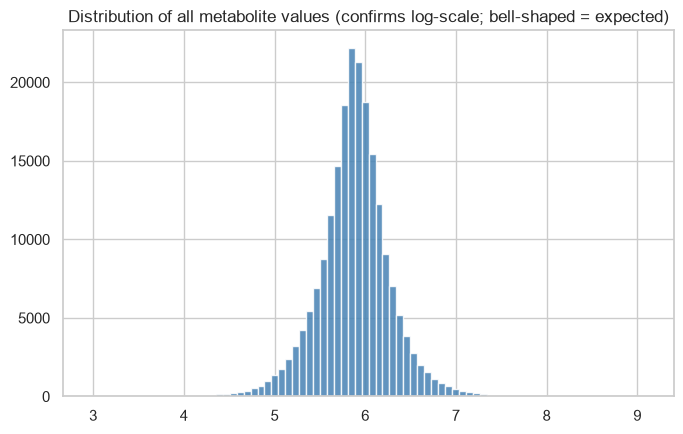

In [3]:
sample_vals = df[met_cols].values.flatten()
sample_vals = sample_vals[~np.isnan(sample_vals)]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(sample_vals, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title('Distribution of all metabolite values (confirms log-scale; bell-shaped = expected)')
plt.tight_layout(); plt.show()

### Why this EDA check matters

Confirms the already-log-transformed claim (a bell-shaped, moderate-range distribution, not the
raw right-skew seen in un-transformed layers like GEO expression), and the near-complete
`DepMap_ID` coverage that makes the primary join simple when it succeeds.

## 2. Most variable metabolites and co-regulation structure

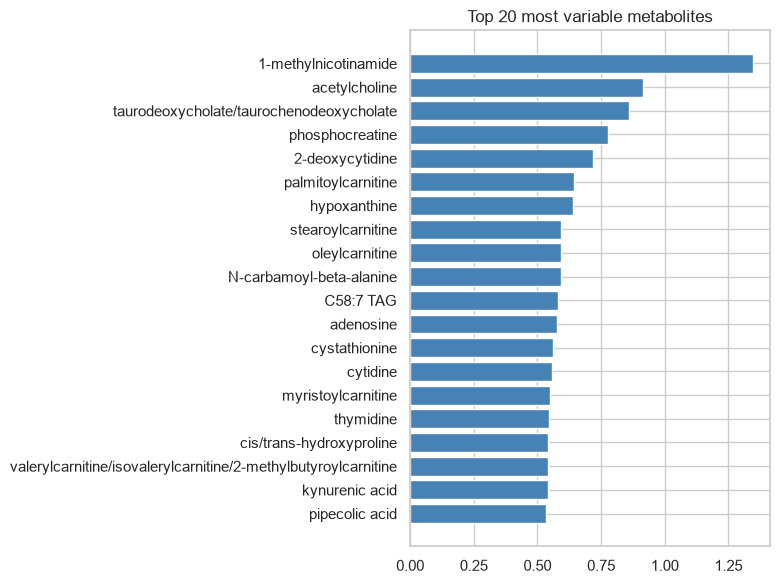

In [4]:
met_std = df[met_cols].std().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
top20 = met_std.head(20)
ax.barh(top20.index[::-1], top20.values[::-1], color='steelblue')
ax.set_title('Top 20 most variable metabolites')
plt.tight_layout(); plt.show()

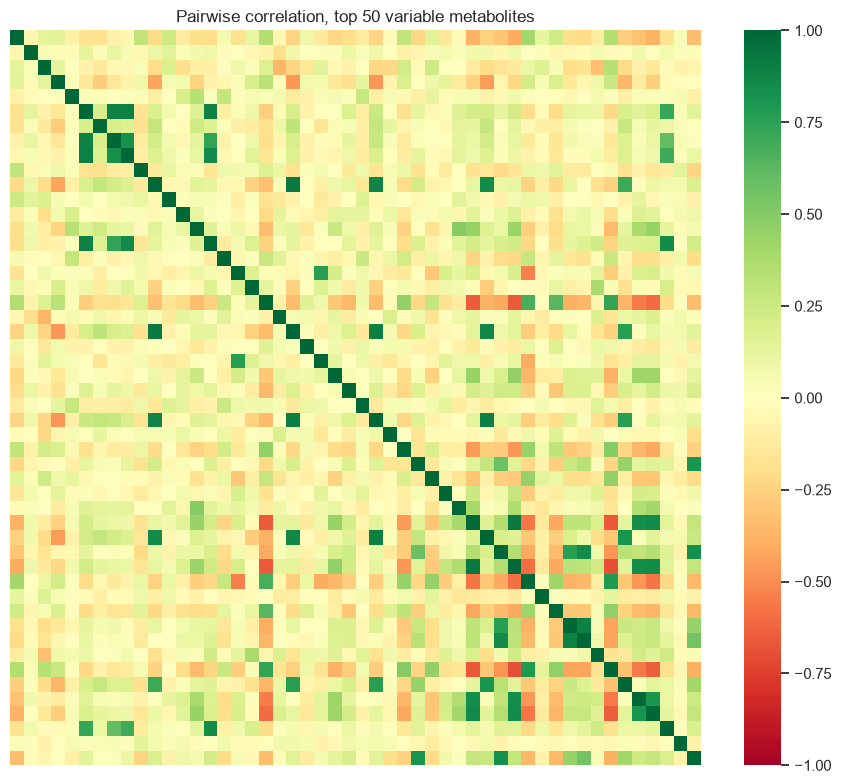

In [5]:
top50 = met_std.head(50).index
corr50 = df[top50].corr()
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(corr50, cmap='RdYlGn', center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=False, yticklabels=False)
ax.set_title('Pairwise correlation, top 50 variable metabolites')
plt.tight_layout(); plt.show()

### Why this EDA check matters

Blocks of correlated metabolites (expected: amino acid clusters, lipid clusters) indicate
co-regulated metabolic programs rather than 225 independent readings — relevant if this layer is
ever used as multiple context features rather than one aggregate signal, since correlated features
would need the same CAMERA-style discount `docs/PROJECT_ARCHITECTURE.md` §5(d) applies to genes.

## 3. Lineage structure in PCA

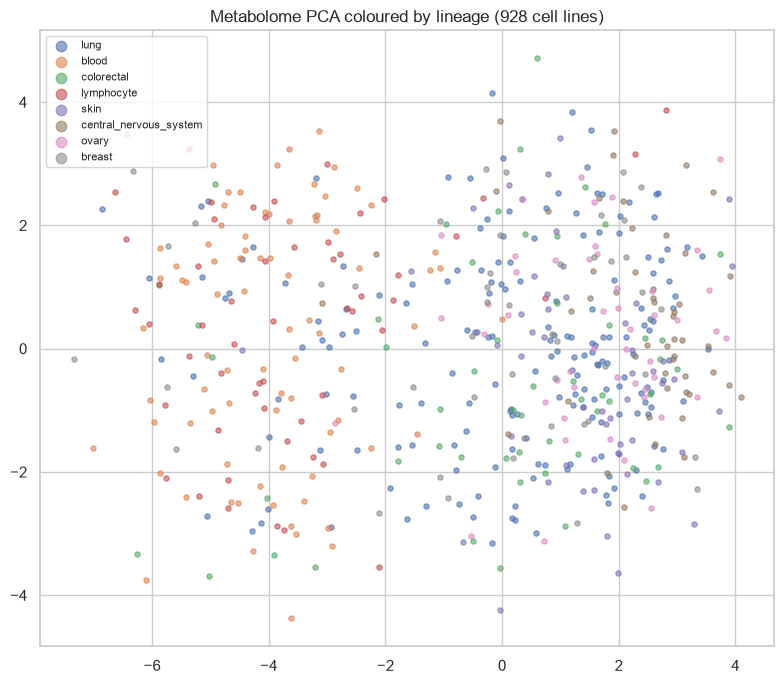

In [6]:
df9 = pd.read_csv(NOMENCLATURE / '9_DepMap_sample_info.csv', usecols=['DepMap_ID', 'lineage'])
lineage = df9.set_index('DepMap_ID')['lineage']

X = df[met_cols].dropna(axis=1)
coords = PCA(n_components=2, random_state=42).fit_transform(X.values)
lins = df['DepMap_ID'].map(lineage).values
top_lineages = pd.Series(lins).value_counts().head(8).index

fig, ax = plt.subplots(figsize=(8, 7))
for lin in top_lineages:
    mask = lins == lin
    ax.scatter(coords[mask, 0], coords[mask, 1], s=14, alpha=0.6, label=lin)
ax.legend(fontsize=8, markerscale=2)
ax.set_title(f'Metabolome PCA coloured by lineage ({len(df)} cell lines)')
plt.tight_layout(); plt.show()

### Why this EDA check matters

Even though metabolomics is expected to fail the gene-addressable criterion, it can still be a
useful **model-level context filter** if it carries real lineage signal — visible clustering here
supports keeping it as reported context even without a per-gene score. **Descriptive only**, per
root `_.md` §3.

## 4. Identity join and coverage bias

Metabolomics cell lines reaching primary spine: 927 of 1840 (50.4%)


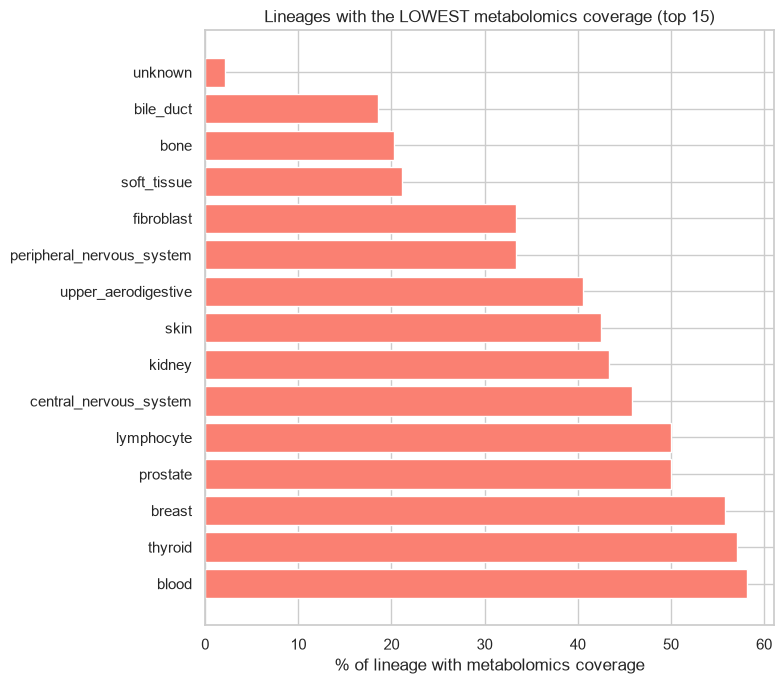

In [7]:
df9_full = pd.read_csv(NOMENCLATURE / '9_DepMap_sample_info.csv', usecols=['DepMap_ID', 'lineage'])
matched = set(df['DepMap_ID'].dropna()) & set(df9_full['DepMap_ID'])
covered = df9_full[df9_full['DepMap_ID'].isin(matched)]
total_per = df9_full['lineage'].value_counts()
covered_per = covered['lineage'].value_counts()
coverage_pct = (covered_per / total_per * 100).dropna().sort_values()

print(f"Metabolomics cell lines reaching primary spine: {len(matched)} of {df9_full['DepMap_ID'].nunique()} ({len(matched)/df9_full['DepMap_ID'].nunique():.1%})")
fig, ax = plt.subplots(figsize=(8, 7))
bottom15 = coverage_pct.head(15)
ax.barh(bottom15.index[::-1], bottom15.values[::-1], color='salmon')
ax.set_xlabel('% of lineage with metabolomics coverage')
ax.set_title('Lineages with the LOWEST metabolomics coverage (top 15)')
plt.tight_layout(); plt.show()

### Why this EDA check matters

Roughly half the catalogue has no metabolomics measurement at all — this is the A2 (coverage)
evidence for the admission-gate table, independent of the A1 verdict.

## Decisions carried into the next notebooks

1. **This layer has no per-gene mapping** — a metabolite is not addressable by an arbitrary
   query gene. This confirms `docs/PROJECT_ARCHITECTURE.md` §6's expectation: metabolomics is a
   candidate for **model-level context/filter**, not a scored per-gene layer, pending §6's formal
   verdict in `docs/plan/METHOD_DECISION.md`.
2. Metabolites cluster into co-regulated groups (§2) — if used as multiple context features, they
   need the same correlation discount genes get.
3. Coverage is ~50% of the primary spine and lineage-biased (§4) — must be disclosed if used at all.
4. **Limitation:** the release date (2019-05-02) predates the modern DepMap schema
   (`docs/PROJECT_ARCHITECTURE.md` §2's release-mismatch caution) — treat this as a distinct
   snapshot, never silently pooled with newer-release layers.